In [1]:
import numpy as np
import matplotlib.pyplot as plt
from qutip import *

GKP logical qubits are continous variables

$$ \ket{0}_L = \sum^{\infty}_{k = 0} \ket{2k\pi} \qquad \ket{1}_L = \sum^{\infty}_{k = 0} \ket{(2k+1)\pi}$$

we can simulate these by picking a large value N instead of infinity, and parameters to squeeze and build the peaks of these states.

These quits manifest as lattice sites in phase space, that can be displayed as a porbability density function called the Wiegner (check spelling) function. This gives the probability of the qubit exisiting in given momentum (or momenta -check) and position. 

All qubits experience errors on their information. In these gkp qubits, the errors can appear in both momentum and position, cannot correct for both uncertinty princile

Squeeze the qubit so most of it lies iin just one of the axis in phase space - then most errors just in one side

In [2]:
#parameters
N = 200 # needs to be large
delta = 0.3 # to sqeeeze
epsilon = 0.2 
n = 6 #gkp qubit peaks
noise = 0.5 # for displacement noise
#kappa = 0.0 # photon loss
#t_loss = 0.1 # time
n_trials = 500 # for monte carlo

sqrt_pi = np.sqrt(np.pi) # to write less later on

def GKP_built(N, delta, epsilon, n):
    #vaccum
    vac = basis(N, 0)

    #squeezing - narrow gauss - stat phys
    r = -np.log(delta) 
    S = squeeze(N, r)
    peak_state = S * vac

    # gkp logical 0
    # = sum k | q = 2k sqrt pi>
    gkp = 0 #sets it to zero state rather than 1
    for k in range(-n, n + 1):
        weight = np.exp(-2 * np.pi * epsilon**2 * k**2)
        D = displace(N, 2 * k * np.sqrt(np.pi))
        gkp += weight * D * peak_state

    return gkp.unit()

state = GKP_built(N, delta, epsilon, n)

then the noise, which is a displacement to the latice can be modeled using guassian noise functions in momentum and position space

we want to then apply these random displacements to the qubit



hello2
hello3


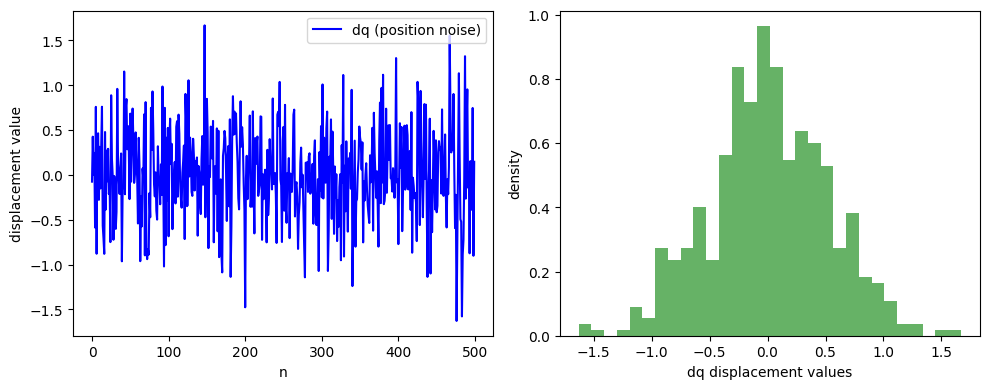

In [ ]:
noise_state = []
dq_vals = []
dp_vals = []

#noise

def dq_and_dp(noise):
    dq = np.random.normal(0, noise, size=n_trials)
    dp = np.random.normal(0, noise, size=n_trials)
    
    return dq, dp

print("hello2")

def displacement(state, noise): #gaussian noise abour 0 to get displacement values for each qubit
    dq, dp = dq_and_dp(noise)
    for i in range(n_trials):
        D = displace(N, dq[i] + 1j * dp[i]) # do dq and dp can act on state
        noise_state.append((D*state).unit())
    return noise_state, dp, dq

noise_states, dq_vals, dp_vals = displacement(state, noise)

print("hello3")

#gaussian plots - need to do for n trials so far only gets one value
plt.figure(figsize=(10, 4))

#position q noise
plt.subplot(1, 2, 1)
plt.plot(range(n_trials), dq_vals, label='dq (position noise)', color='blue')
plt.xlabel('n')
plt.ylabel('displacement value')
plt.legend()

# histogram
plt.subplot(1, 2, 2)
plt.hist(dq_vals, bins=30, density=True, alpha=0.6, color='g')
plt.xlabel('dq displacement values')
plt.ylabel('density')
plt.tight_layout()
plt.show()

the stabilisers are now also continuous variables 

these can then be checked in a similar way as commutation relations for fermionic qubits in these steps 
- find expectation value of stabiliser on the noisy state
- find the phase values for both momentum and position
- use the shift expectation and phase to find the syndrome
- find a confidence value for the syndrome

This confidence value is there because large the displacement of a 0 qubit to a 1 looks like the same as the small displacement of a 1 qubit. The former being an error and the latter is not, so the confidence value tells us how confident we are that the syndrome correctly displays an error or not.

In [4]:
#stabilisers for gkp qubits
#finding the expectation value of each state with the stabs gets a complex number
#this then used in the syndrome value process

#sq = e^(-i2 *sqrt pi *p^)
Sq = displace(N, 2 * sqrt_pi)

#sp = e^(i2 * sqrt_pi * x^

Sp = displace(N, 2*1j*sqrt_pi)

syndrome_q = []
syndrome_p = []
phases_q = []
phases_p = []
conf_q = []
conf_p = []
gamma_q = []
gamma_p = []

# now we want to use p and q vals but without knowing the origional state value
#should there also be other initial states then? and not just |0>
# noise state is the noise_psi is individual states

def syndrome(Sq, Sp, noise_states):
    for noise_psi in noise_states:
        #get expectation value for preliminary syndrome stuff s^_
        s_q = expect(Sq, noise_psi)
        phase_q = np.angle(s_q)
        s_p = expect(Sp, noise_psi)
        phase_p = np.angle(s_p)

        #boundary is at sqrt pi /2
        #get continuous value thing
        # this gets the expectation value back into gkp lattic terms i think idk
        sq0 = phase_q/(2*sqrt_pi) # bc its in radians
        sp0 = phase_p/(2*sqrt_pi)
        sq = ((sq0 + sqrt_pi/2) % (sqrt_pi)) - sqrt_pi/2
        sp = ((sp0 + sqrt_pi/2) % (sqrt_pi)) - sqrt_pi/2

        #confident of syndrome
        cq = 1 - abs(sq)/(sqrt_pi/2)
        cp = 1 - abs(sp)/(sqrt_pi/2)

        #gamma value thing from papaer - but no hardware or readout noise accounted for yet
        gq = 2 * sq / noise**2
        gp = 2 * sp / noise**2

        syndrome_q.append(sq)
        syndrome_p.append(sp) 
        conf_q.append(cq)
        conf_p.append(cp)
        gamma_q.append(gq)
        gamma_p.append(gp)

    return syndrome_q, syndrome_p, phase_q, phase_p, conf_q, conf_p, gamma_q, gamma_p

syndrome_q, syndrome_p, pq, pp, cq, cp, gq, gp = syndrome(Sq, Sp, noise_states)

These syndrome values can be plotted between the limits of 1 and -1 where 1 is an error in the positive displacemenet and -1 in the negative.

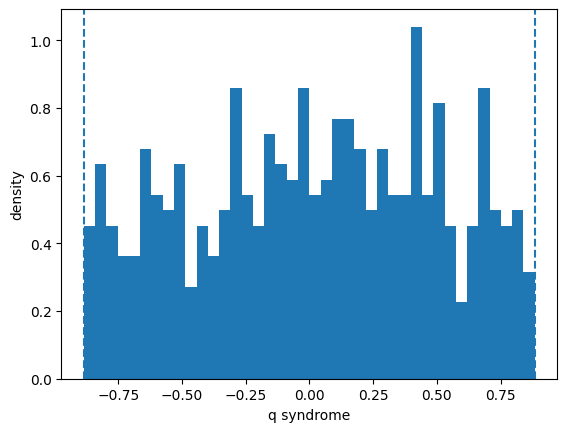

In [5]:
plt.hist(syndrome_q, bins=40, density=True)
plt.axvline(np.sqrt(np.pi)/2, linestyle='--')
plt.axvline(-np.sqrt(np.pi)/2, linestyle='--')
plt.xlabel("q syndrome")
plt.ylabel("density")
plt.show()

This above just deals with the starting qubit as 0 so even tho some values were not corrected back to this we know what it should have been and can see how good the correction process is.

Introducing the 1 qubit allows the errors to occur in sillier ways (add more info)

In [6]:
#now want multiple gkp qubits to be built 
#same parameters as above

def GKP_0(N, delta, epsilon, n):
    #vaccum
    vac = basis(N, 0)

    #squeezing - narrow gauss - stat phys
    r = -np.log(delta) 
    S = squeeze(N, r)
    peak_state = S * vac

    gkp = 0
    for k in range(-n, n + 1):
        weight = np.exp(-2 * np.pi * epsilon**2 * k**2)
        D = displace(N, 2*k * np.sqrt(np.pi))
        gkp += weight * D * peak_state

    return gkp.unit()

ket_0 = GKP_0(N, delta, epsilon, n)

def GKP_1(N, delta, epsilon, n):
    #vaccum
    vac = basis(N, 0)

    #squeezing - narrow gauss - stat phys
    r = -np.log(delta) 
    S = squeeze(N, r)   
    peak_state = S * vac

    gkp = 0
    for k in range(-n, n + 1):
        weight = np.exp(-2 * np.pi * epsilon**2 * k**2)
        D = displace(N, (2*k+1)* np.sqrt(np.pi))
        gkp += weight * D * peak_state

    return gkp.unit()

ket_1 = GKP_1(N, delta, epsilon, n)

alpha = 1/np.sqrt(2)
beta = 1/np.sqrt(2)

ket_1 = (alpha*ket_0 + beta*ket_1).unit()

Make it qubits in surface code

useful things (not papers bc those saved)
- https://errorcorrectionzoo.org/c/gkp_concatenated
- https://pymatching.readthedocs.io/en/latest/toric-code-example.html
- 

First check error rate of gkp qubit

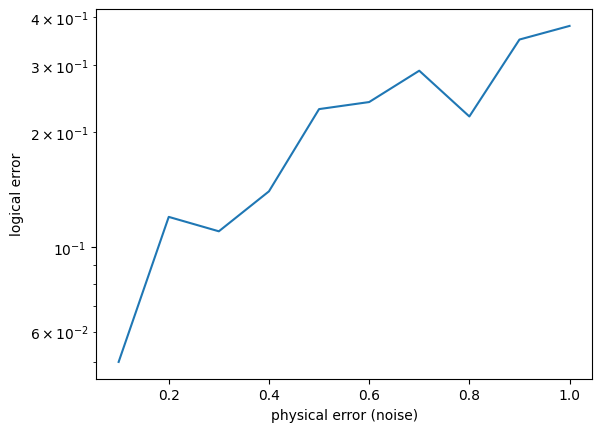

In [7]:
def logical_rate():
    N = 50          
    n_trials = 100 
    noise_vals = np.linspace(0.1, 1.0, 10)
    logical_error_rates = []
    
    state_small = GKP_built(N, delta, epsilon, n)
    Sq_small = displace(N, 2 * sqrt_pi)
    Sp_small = displace(N, 2 * 1j * sqrt_pi)
    
    for noise in noise_vals:
        # generate noise directly here instead of calling displacement()
        dq = np.random.normal(0, noise, size=n_trials)
        dp = np.random.normal(0, noise, size=n_trials)
        
        noise_states = []
        for i in range(n_trials):
            D = displace(N, dq[i] + 1j * dp[i])
            noise_states.append((D * state_small).unit())
        
        # call syndrome with small operators
        syndrome_q, syndrome_p, pq, pp, cq, cp, gq, gp = syndrome(Sq_small, Sp_small, noise_states)
        
        errors = 0
        for i in range(n_trials):
            correction = -syndrome_q[i]
            residual = dq[i] + correction
            if abs(residual) > sqrt_pi / 2:
                errors += 1
        
        logical_error_rates.append(errors / n_trials)
    
    return noise_vals, logical_error_rates

noise_vals, logical_error_rate = logical_rate()

plt.figure()
plt.plot(noise_vals, logical_error_rate)
plt.yscale('log')
plt.xlabel('physical error (noise)')
plt.ylabel('logical error')
plt.show()

Take code from surface an hypergraph code file that builds the Hx and Hz of the reperrttion code for a given distance d

Will do toric code when i have this version working bc seems more complicated - that adds the 3d part

In [12]:
def repetition_code(n):
    H = np.zeros((n-1, n), dtype=int)
    for i in range(n-1):
        H[i, i]   = 1
        H[i, i+1] = 1
    return H

d = 3
H1 = repetition_code(3)
H2 = repetition_code(3)
H2T = H2.T
r1, n1 = H1.shape
r2, n2 = H2.shape
I2T = np.eye(n2, dtype=int) #identity matrix in the shape of the rows of H1 or H2
I1 = np.eye(r1, dtype=int) #identity matrix in the shape of the columns of H1 or H2

def hypergraphHxHz(H1, H2T, I1, I2T):
    """
    Args:
        H1 (array?): 3 bit code thing
        H2 (_type_): same as above
        I1 (_type_): identity matrix 
        I2T (_type_): identity matrix

    Returns: 
        Hx, Hz for hypergraph codes
    """
    Hxr = np.kron(H1, I2T)
    Hxl= np.kron(I1, H2T)
    Hx = np.hstack([Hxr, Hxl])

    Hzr = np.kron(I2T, H1)
    Hzl = np.kron(H2T, I1)
    Hz = np.hstack([Hzr, Hzl])
    return Hx, Hz

Hx, Hz = hypergraphHxHz(H1, H2T, I1, I2T)

print(Hx, Hz)

[[1 0 0 1 0 0 0 0 0 1 0 0 0]
 [0 1 0 0 1 0 0 0 0 1 1 0 0]
 [0 0 1 0 0 1 0 0 0 0 1 0 0]
 [0 0 0 1 0 0 1 0 0 0 0 1 0]
 [0 0 0 0 1 0 0 1 0 0 0 1 1]
 [0 0 0 0 0 1 0 0 1 0 0 0 1]] [[1 1 0 0 0 0 0 0 0 1 0 0 0]
 [0 1 1 0 0 0 0 0 0 0 1 0 0]
 [0 0 0 1 1 0 0 0 0 1 0 1 0]
 [0 0 0 0 1 1 0 0 0 0 1 0 1]
 [0 0 0 0 0 0 1 1 0 0 0 1 0]
 [0 0 0 0 0 0 0 1 1 0 0 0 1]]


The code below uses Hz to check for errors dq in position space

In [10]:
import pymatching

def get_logical_z(d):
    r = d - 1  # rows of H
    n = d      # cols of H
    n_top = n * n        # = d²
    n_bot = r * r        # = (d-1)²
    n_qubits = n_top + n_bot

    logical = np.zeros(n_qubits, dtype=np.uint8)
    for i in range(n):
        logical[i * n] = 1
    return logical

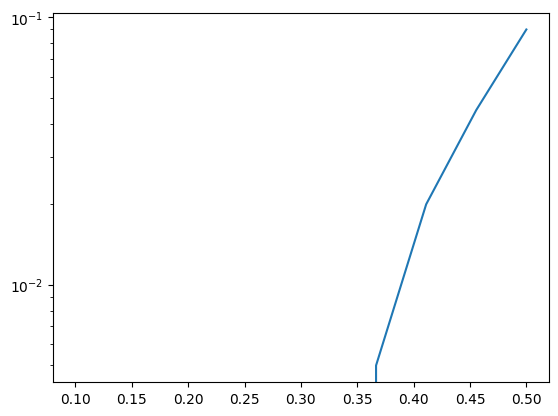

In [14]:
def gkp_surface_code(Hz, d, noise, n_trials):
    """_summary_

    Args:
        Hz (_type_): wheer z type stabilisers appear
        d (_type_): distace of code
        noise (_type_): error rates
        n_trials (_type_): _description_
    """
    N = 50
    n_qubits = Hz.shape[1]
    n_checks = Hz.shape[0]

    state_small = GKP_built(N, delta, epsilon, n)
    Sq_small = displace(N, 2 * sqrt_pi)

    matcher = pymatching.Matching.from_check_matrix(Hz) 

    failures = 0

    for _ in range (n_trials):
        # noise
        dq = np.random.normal(0, noise, size = n_qubits)

        syndrome_bits = np.zeros(n_checks, dtype = int)

        for q in range (n_qubits):
            # displace each qubit
            D = displace(N, dq[q])
            noisy = (D * state_small).unit()

            #syndrome values in a similar method to the start of this file
            s_q = expect(Sq_small, noisy)
            phase_q = np.angle(s_q)
            sq0 = phase_q / (2*sqrt_pi)
            sq = ((sq0 + sqrt_pi/2) % sqrt_pi) - sqrt_pi

        binary_errors = (np.abs(dq) > sqrt_pi/2).astype(int)
        syndrome_bits = (Hz @ binary_errors) % 2

        correction = matcher.decode(syndrome_bits)

        logical_z = get_logical_z(d)
        residual = (binary_errors ^ correction)
        if (residual @ logical_z) % 2 == 1:
            failures += 1

    return failures / n_trials

noise_vals = np.linspace(0.1, 0.5, 10)
rates = [gkp_surface_code(Hz, d=3, noise=n, n_trials=200) for n in noise_vals]

plt.figure()
plt.plot(noise_vals, rates)
plt.yscale('log')
plt.show()